In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Brown1="/content/drive/MyDrive/browniano/Brown1.csv"
Brown2="/content/drive/MyDrive/browniano/Brown2.csv"
Brown3="/content/drive/MyDrive/browniano/Brown3.csv"
Brown4="/content/drive/MyDrive/browniano/Brown4.csv"
Brown5="/content/drive/MyDrive/browniano/Brown5.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as ma

In [ ]:
data1=pd.read_csv(Brown1)
data2=pd.read_csv(Brown2)
data3=pd.read_csv(Brown3)
data4=pd.read_csv(Brown4)
data5=pd.read_csv(Brown5)

In [ ]:
datosx=[]
datosy=[]
for j in range(1,11):
  #print(data1['x'+str(j)][0])
  datosx.append(data1['x'+str(j)]-data1['x'+str(j)][0])
  datosy.append(data1['y'+str(j)]-data1['y'+str(j)][0])

for j in range(1,11):
  #print(data2['x'+str(j)][0])
  datosx.append(data2['x'+str(j)]-data2['x'+str(j)][0])
  datosy.append(data2['y'+str(j)]-data2['y'+str(j)][0])
for j in range(1,11):
  #print(data3['x'+str(j)][0])
  datosx.append(data3['x'+str(j)]-data3['x'+str(j)][0])
  datosy.append(data3['y'+str(j)]-data3['y'+str(j)][0])
for j in range(1,11):
  #print(data4['x'+str(j)][0])
  datosx.append(data4['x'+str(j)]-data4['x'+str(j)][0])
  datosy.append(data4['y'+str(j)]-data4['y'+str(j)][0])
for j in range(1,11):
  #print(data5['x'+str(j)][0])
  datosx.append(data5['x'+str(j)]-data5['x'+str(j)][0])
  datosy.append(data5['y'+str(j)]-data5['y'+str(j)][0])


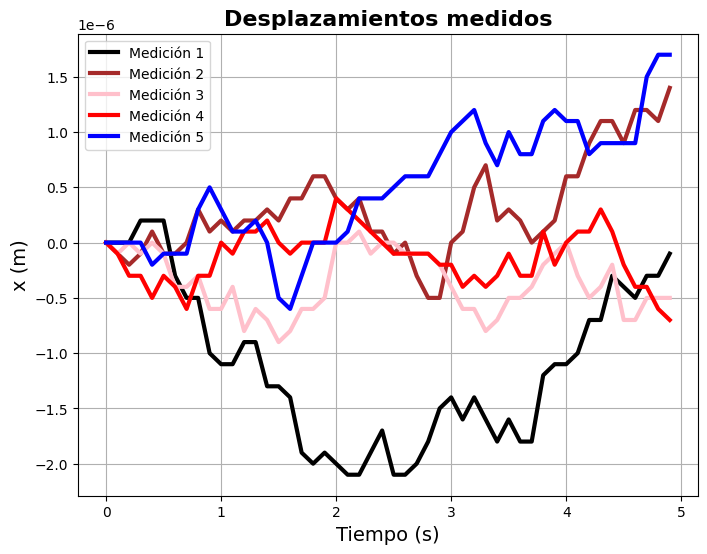

In [ ]:
tmcd=data1['t']
plt.figure(figsize=(8,6))
plt.plot(tmcd,datosx[0],color='black',linewidth=3)
plt.plot(tmcd,datosx[1],color='brown',linewidth=3)
plt.plot(tmcd,datosx[2],color='pink',linewidth=3)
plt.plot(tmcd,datosx[3],color='red',linewidth=3)
plt.plot(tmcd,datosx[4],color='blue',linewidth=3)
plt.title("Desplazamientos medidos",fontsize=16,fontweight='bold')
plt.ylabel("x (m)", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=14)
plt.legend(['Medición 1','Medición 2','Medición 3','Medición 4','Medición 5'])
plt.grid()
plt.show()


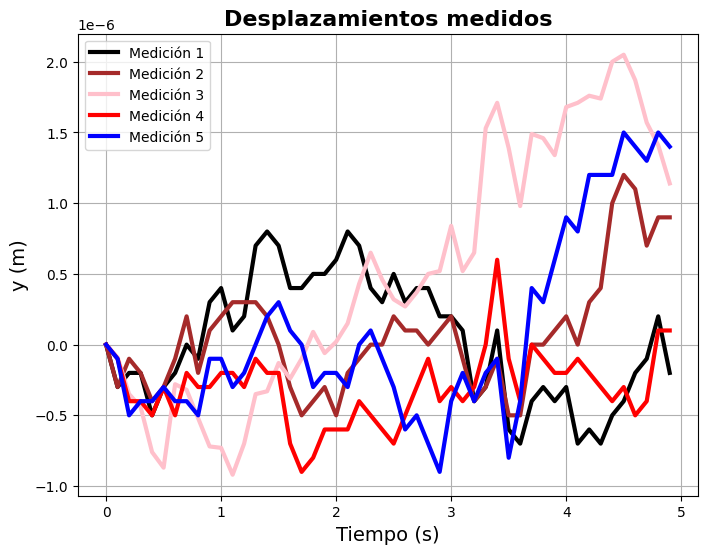

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(tmcd,datosy[0],color='black',linewidth=3)
plt.plot(tmcd,datosy[1],color='brown',linewidth=3)
plt.plot(tmcd,datosy[2],color='pink',linewidth=3)
plt.plot(tmcd,datosy[3],color='red',linewidth=3)
plt.plot(tmcd,datosy[4],color='blue',linewidth=3)
plt.title("Desplazamientos medidos",fontsize=16,fontweight='bold')
plt.ylabel("y (m)", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=14)
plt.legend(['Medición 1','Medición 2','Medición 3','Medición 4','Medición 5'])
plt.grid()
plt.show()

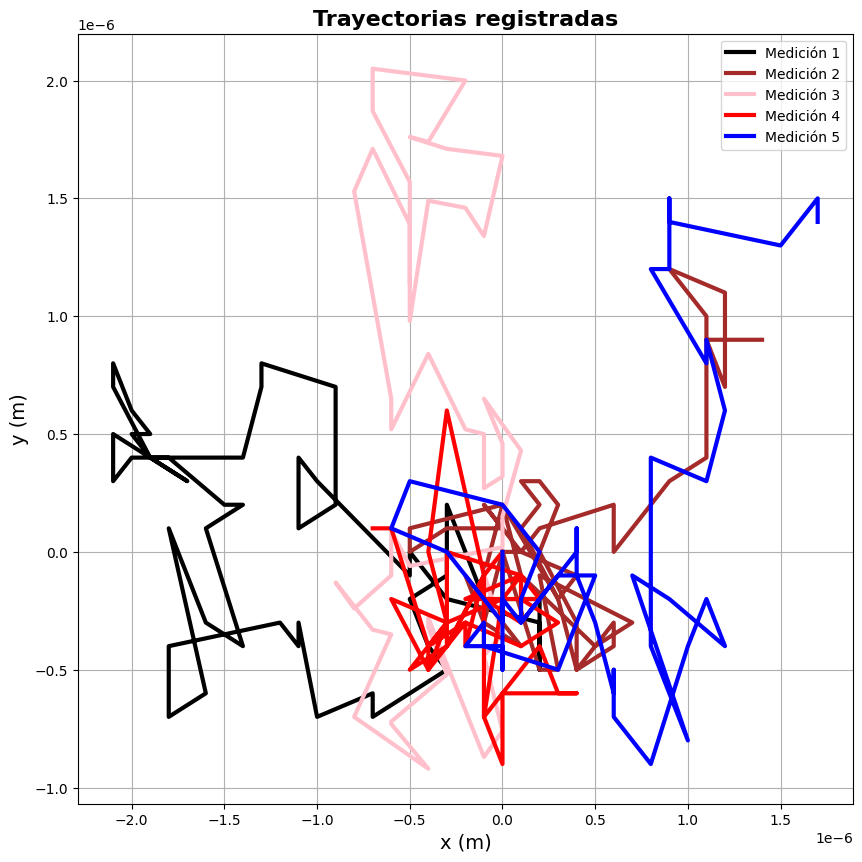

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(datosx[0],datosy[0],color='black',linewidth=3)
plt.plot(datosx[1],datosy[1],color='brown',linewidth=3)
plt.plot(datosx[2],datosy[2],color='pink',linewidth=3)
plt.plot(datosx[3],datosy[3],color='red',linewidth=3)
plt.plot(datosx[4],datosy[4],color='blue',linewidth=3)
plt.title("Trayectorias registradas",fontsize=16,fontweight='bold')
plt.ylabel("y (m)", fontsize=14)
plt.xlabel("x (m)", fontsize=14)
plt.legend(['Medición 1','Medición 2','Medición 3','Medición 4','Medición 5'])
plt.grid()
plt.show()

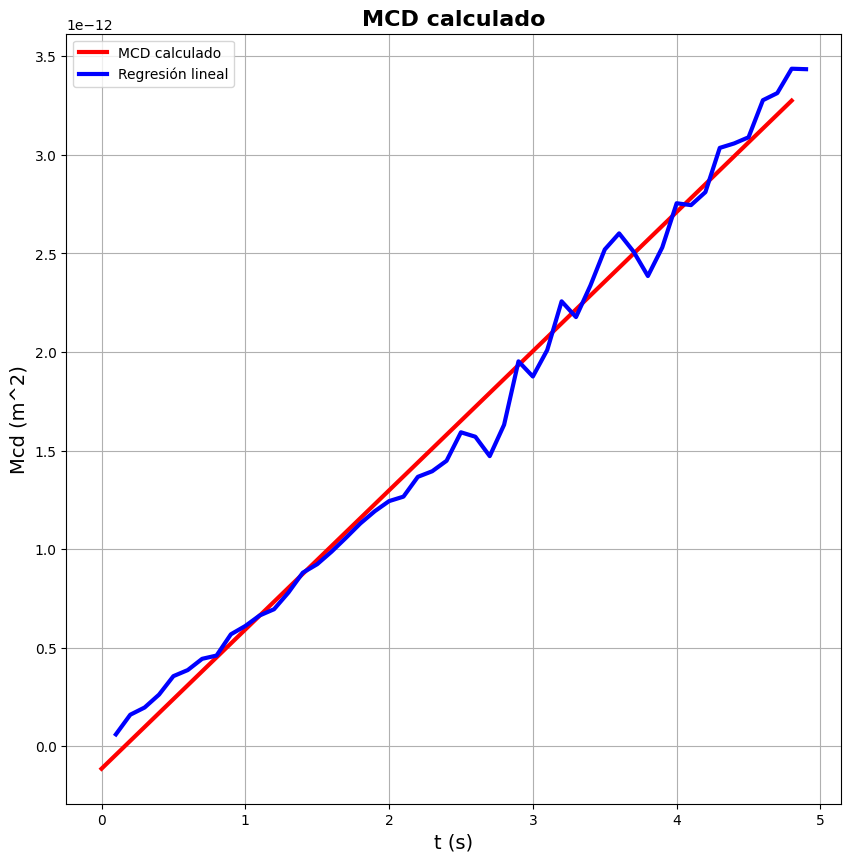

pendiente = 7.060247813411074e-13
intercepto = -1.1358011245314411e-13
coeficiente de difusion:  1.7650619533527685e-13


In [ ]:
mcds=[]
n=1
for i in range(0,len(datosx[0])-n):
  listaa=[]
  for j in range(0,len(datosx)):
    listaa.append(((datosx[j][i+n])**2+(datosy[j][i+n])**2)/(len(datosx)-n))
  mcds.append(sum(listaa))
tmcd=data1['t']
tmcd.pop(0)
m, b = np.polyfit(tmcd, mcds, 1)
t=np.linspace(0,tmcd[48])

plt.figure(figsize=(10,10))
plt.plot(t,m*t+b,linewidth=3,color='red')
plt.plot(tmcd[0:len(mcds)],mcds,linewidth=3,color='blue')
plt.title("MCD calculado",fontsize=16,fontweight='bold')
plt.ylabel("Mcd (m^2)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.legend(['MCD calculado','Regresión lineal'])
plt.grid()
plt.show()
print("pendiente =", m)
print("intercepto =", b)
print("coeficiente de difusion: ", m/4)

In [ ]:
from scipy.stats import linregress

result = linregress(tmcd, mcds)

m = result.slope
b = result.intercept
dm = result.stderr
db = result.intercept_stderr

print("D con error", m/4, "±", dm/4)

D con error 1.7650619533527687e-13 ± 2.708665727037591e-15


24 24


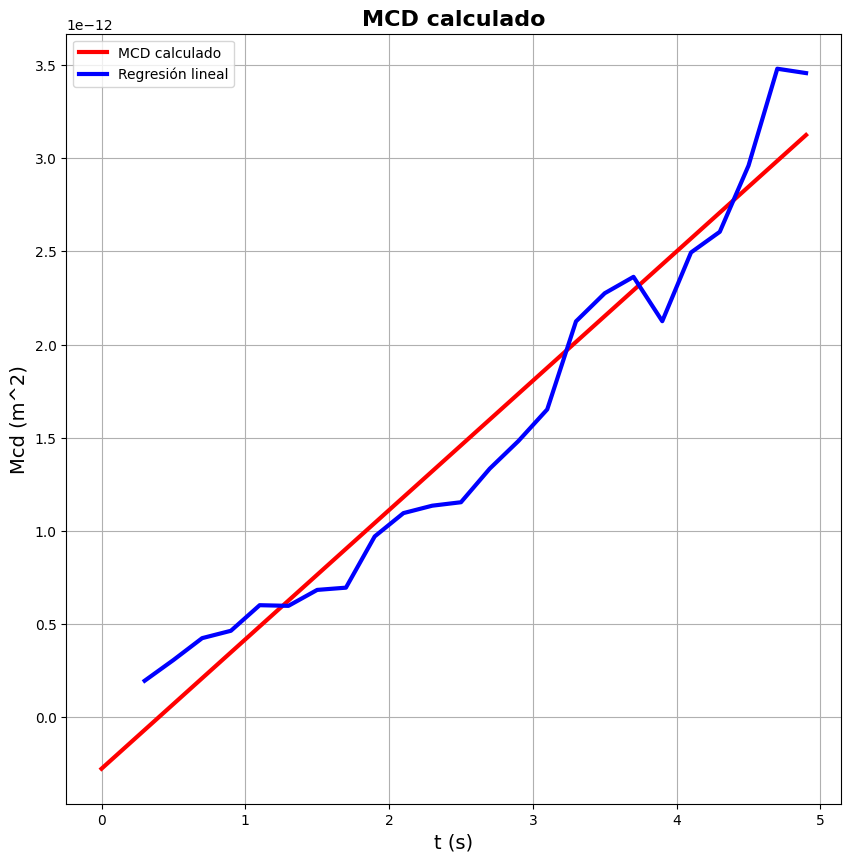

pendiente = 6.941005797101453e-13
intercepto = -2.7662574335748707e-13
coeficiente de difusion:  1.7352514492753633e-13


In [ ]:
newx=[]
newy=[]
newt=[]
n=2
tm = data1['t'].copy().to_list() # Get a fresh copy of 't' column and convert it to a list
tm.append(tm[len(tm)-1]+0.1)
for i in range(0,len(datosx)):
  lista1=[]
  lista2=[]
  for j in range(0,int(len(datosx[0])/2)):
      lista1.append(datosy[i][j*n])
      lista2.append(datosy[i][j*n])
  newx.append(lista1)
  newy.append(lista2)
for j in range(0,int(len(datosx[0])/2)):
  newt.append(tm[j*n])

datosx=newx
datosy=newy
tmcd=newt
tmcd.pop(0)
mcds=[]
for i in range(0,len(datosx[0])-1):
  listaa=[]
  for j in range(0,len(datosx)):
    listaa.append(((datosx[j][i+1])**2+(datosy[j][i+1])**2)/(50-n))
  mcds.append(sum(listaa))
print(len(tmcd),len(mcds))
m, b = np.polyfit(tmcd, mcds, 1)
t=np.linspace(0,tmcd[23])

plt.figure(figsize=(10,10))
plt.plot(t,m*t+b,linewidth=3,color='red')
plt.plot(tmcd[0:len(mcds)],mcds,linewidth=3,color='blue')
plt.title("MCD calculado",fontsize=16,fontweight='bold')
plt.ylabel("Mcd (m^2)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.legend(['MCD calculado','Regresión lineal'])
plt.grid()
plt.show()
print("pendiente =", m)
print("intercepto =", b)
print("coeficiente de difusion: ", m/4)

In [ ]:
result = linregress(tmcd, mcds)

m = result.slope
b = result.intercept
dm = result.stderr
db = result.intercept_stderr

print("D con error", m/4, "±", dm/4)

D con error 1.735251449275363e-13 ± 8.174187202940875e-15


In [ ]:
datosx=[]
datosy=[]
for j in range(1,11):
  #print(data1['x'+str(j)][0])
  datosx.append(data1['x'+str(j)]-data1['x'+str(j)][0])
  datosy.append(data1['y'+str(j)]-data1['y'+str(j)][0])

for j in range(1,11):
  #print(data2['x'+str(j)][0])
  datosx.append(data2['x'+str(j)]-data2['x'+str(j)][0])
  datosy.append(data2['y'+str(j)]-data2['y'+str(j)][0])
for j in range(1,11):
  #print(data3['x'+str(j)][0])
  datosx.append(data3['x'+str(j)]-data3['x'+str(j)][0])
  datosy.append(data3['y'+str(j)]-data3['y'+str(j)][0])
for j in range(1,11):
  #print(data4['x'+str(j)][0])
  datosx.append(data4['x'+str(j)]-data4['x'+str(j)][0])
  datosy.append(data4['y'+str(j)]-data4['y'+str(j)][0])
for j in range(1,11):
  #print(data5['x'+str(j)][0])
  datosx.append(data5['x'+str(j)]-data5['x'+str(j)][0])
  datosy.append(data5['y'+str(j)]-data5['y'+str(j)][0])

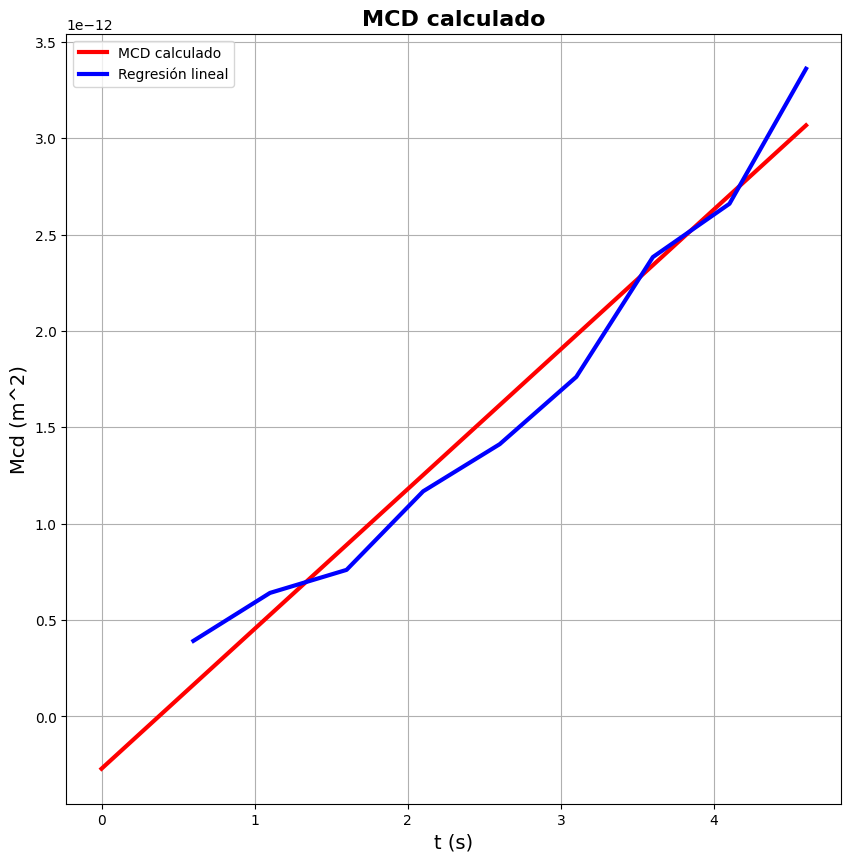

pendiente = 7.257645925925926e-13
intercepto = -2.7118744691357817e-13
coeficiente de difusion:  1.8144114814814816e-13


In [ ]:
newx=[]
newy=[]
newt=[]
n=5
tm = data1['t'].copy().to_list() # Get a fresh copy of 't' column and convert it to a list
tm.append(tm[len(tm)-1]+0.1)
for i in range(0,len(datosx)):
  lista1=[]
  lista2=[]
  for j in range(0,int(len(datosx[0])/n)):
      lista1.append(datosy[i][j*n])
      lista2.append(datosy[i][j*n])
  newx.append(lista1)
  newy.append(lista2)
for j in range(0,int(len(datosx[0])/n)):
  newt.append(tm[j*n])

datosx=newx
datosy=newy
tmcd=newt
tmcd.pop(0)
mcds=[]
for i in range(0,len(datosx[0])-1):
  listaa=[]
  for j in range(0,len(datosx)):
    listaa.append(((datosx[j][i+1])**2+(datosy[j][i+1])**2)/(50-n))
  mcds.append(sum(listaa))
m, b = np.polyfit(tmcd, mcds, 1)
t=np.linspace(0,tmcd[8])

plt.figure(figsize=(10,10))
plt.plot(t,m*t+b,linewidth=3,color='red')
plt.plot(tmcd[0:len(mcds)],mcds,linewidth=3,color='blue')
plt.title("MCD calculado",fontsize=16,fontweight='bold')
plt.ylabel("Mcd (m^2)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.legend(['MCD calculado','Regresión lineal'])
plt.grid()
plt.show()
print("pendiente =", m)
print("intercepto =", b)
print("coeficiente de difusion: ", m/4)

In [ ]:
result = linregress(tmcd, mcds)

m = result.slope
b = result.intercept
dm = result.stderr
db = result.intercept_stderr

print("D con error", m/4, "±", dm/4)

D con error 1.8144114814814818e-13 ± 1.2605137712589593e-14
